In [1]:
import os
import glob

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


sns.set_theme()

In [3]:
processed_data = r"C:\Users\erik-\OneDrive\Escritorio\UPIIT\proyecto_actualizaciones"

features_file = os.path.join(processed_data, "NUSW-NB15_features.csv")

feature_names_df = pd.read_csv(features_file, encoding='latin-1')
FEATURE_NAMES = feature_names_df["Name"].str.strip().tolist()

print(f"Columnas cargadas desde {os.path.basename(features_file)}: {len(FEATURE_NAMES)}")
print(FEATURE_NAMES)

Columnas cargadas desde NUSW-NB15_features.csv: 49
['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'Sload', 'Dload', 'Spkts', 'Dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'Sjit', 'Djit', 'Stime', 'Ltime', 'Sintpkt', 'Dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'Label']


In [4]:
# Buscar archivos de datos, excluyendo el archivo de features
archivos = sorted([
    f for f in glob.glob(os.path.join(processed_data, "*.csv"))
    if "features" not in os.path.basename(f).lower()
])

print(f"Archivos encontrados: {len(archivos)}\n")

for archivo in archivos:
    nombre = os.path.basename(archivo)
    print(nombre)

    df = pd.read_csv(
        archivo,
        header=None,          # los CSV no tienen fila de encabezado
        names=FEATURE_NAMES,  # nombres leídos del archivo de features
        encoding='latin-1',   # evita el UnicodeDecodeError con byte 0x92
        low_memory=False
    )

    print(f"  Filas:    {df.shape[0]:,}")
    print(f"  Columnas: {df.shape[1]}")
    print(f"  Label (0=normal, 1=ataque):")
    print(df["Label"].value_counts().rename({0: "Normal", 1: "Ataque"}).to_string(header=False))
    print()

Archivos encontrados: 4

UNSW-NB15_1.csv
  Filas:    700,001
  Columnas: 49
  Label (0=normal, 1=ataque):
Normal    677786
Ataque     22215

UNSW-NB15_2.csv
  Filas:    700,001
  Columnas: 49
  Label (0=normal, 1=ataque):
Normal    647252
Ataque     52749

UNSW-NB15_3.csv
  Filas:    700,001
  Columnas: 49
  Label (0=normal, 1=ataque):
Normal    542576
Ataque    157425

UNSW-NB15_4.csv
  Filas:    440,044
  Columnas: 49
  Label (0=normal, 1=ataque):
Normal    351150
Ataque     88894



In [5]:
# Cambiar el nombre al archivo que quieras analizar
nombre_archivo = "UNSW-NB15_1.csv"

df = pd.read_csv(
    os.path.join(processed_data, nombre_archivo),
    header=None,
    names=FEATURE_NAMES,
    encoding='latin-1',
    low_memory=False
)

# Stime es Unix epoch (segundos) → convertir a datetime real
df["time"] = pd.to_datetime(df["Stime"], unit="s")

# Ordenar cronológicamente por el timestamp real
df = df.sort_values("time").reset_index(drop=True)

# Etiqueta binaria (Label ya es 0/1 en UNSW-NB15)
df["Anomaly"] = df["Label"].astype(int)

print(f"Rango temporal:")
print(f"  Inicio: {df['time'].min()}")
print(f"  Fin:    {df['time'].max()}")
print(f"\nDistribución de etiquetas:")
print(df["Label"].value_counts().rename({0: "Normal", 1: "Ataque"}))
print(f"\nCategorías de ataque:")
print(df[df["Label"]==1]["attack_cat"].value_counts())

Rango temporal:
  Inicio: 2015-01-22 11:49:37
  Fin:    2015-01-22 19:44:02

Distribución de etiquetas:
Label
Normal    677786
Ataque     22215
Name: count, dtype: int64

Categorías de ataque:
attack_cat
Generic           7522
Exploits          5409
 Fuzzers          5051
Reconnaissance    1759
DoS               1167
Backdoors          534
Analysis           526
Shellcode          223
Worms               24
Name: count, dtype: int64


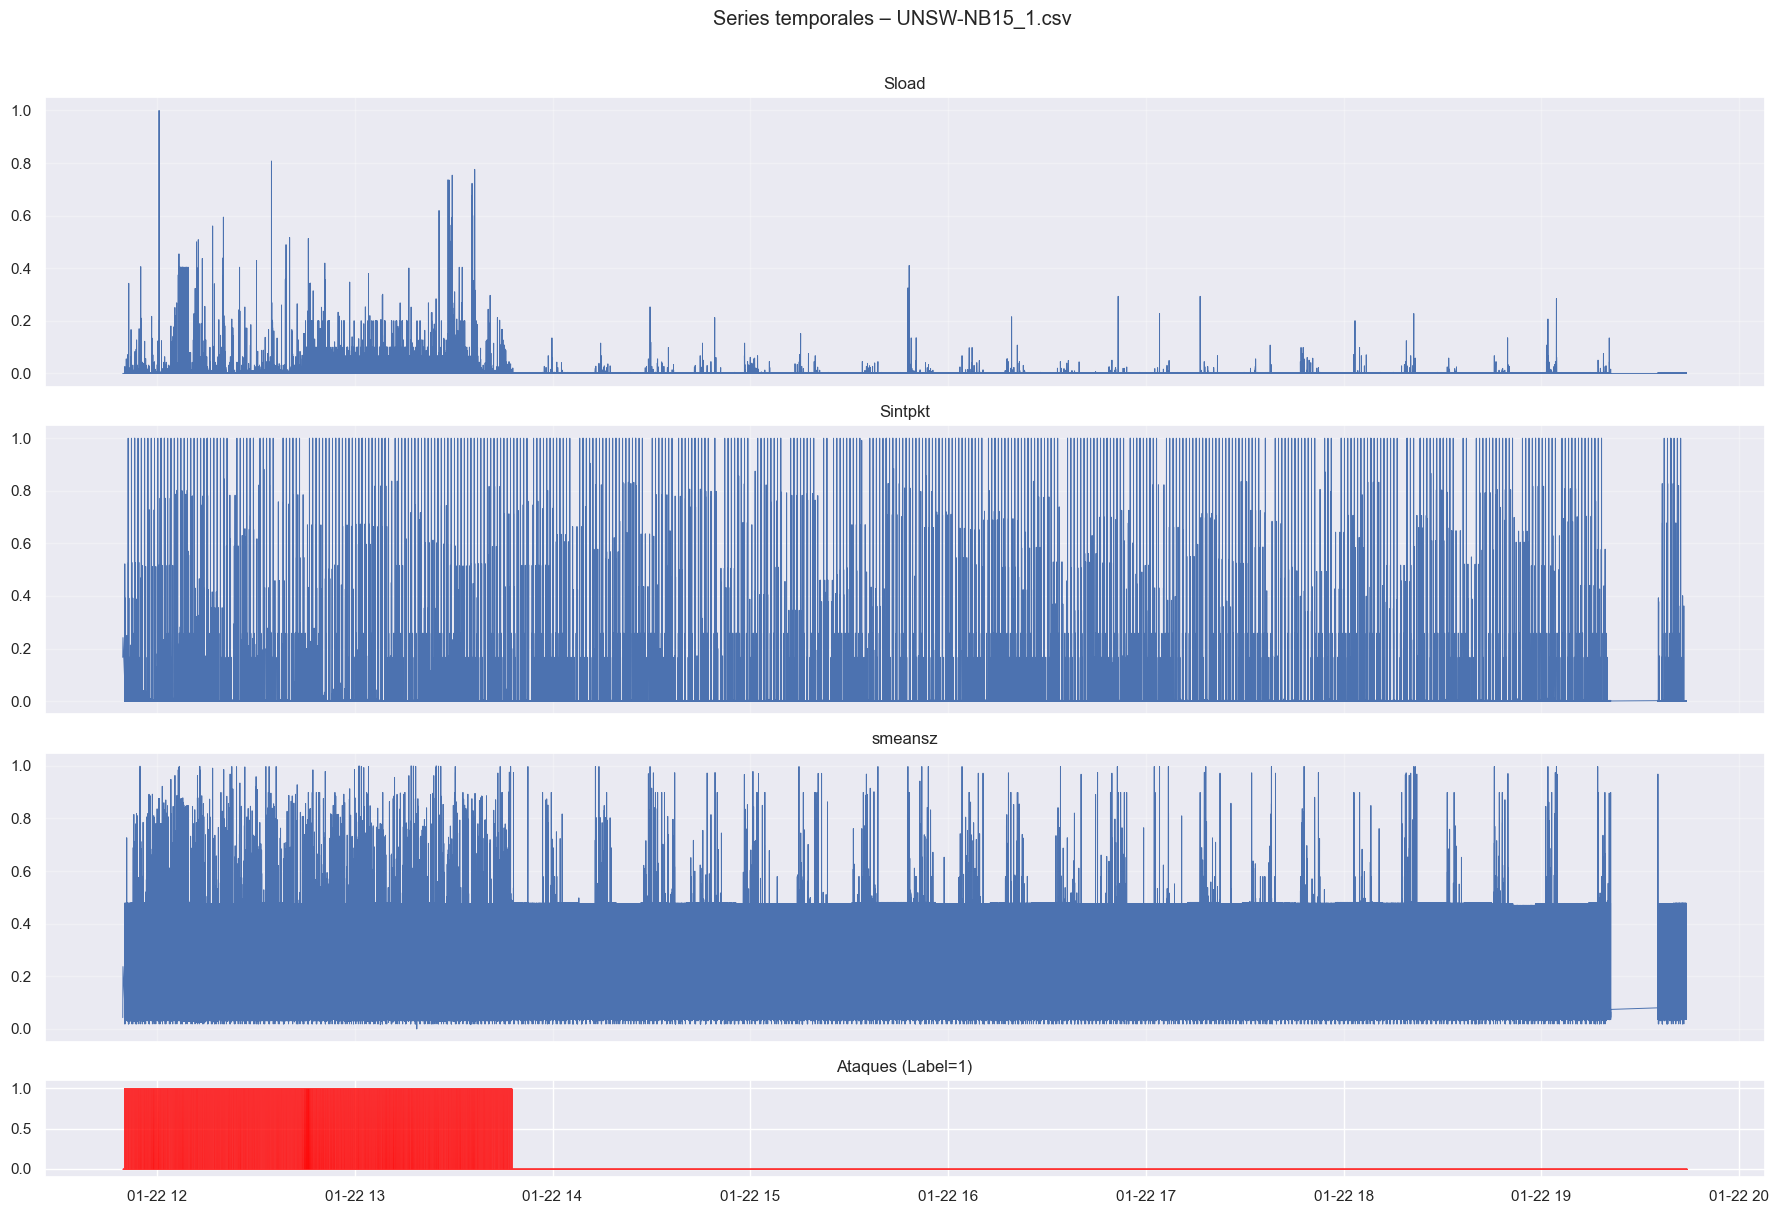

In [6]:
variables = [
    'Sload',
    'Sintpkt',
    'smeansz',
]

df_plot = df.copy()

df_plot[variables] = (
    df_plot[variables]
    .replace([np.inf, -np.inf], np.nan)
)

scaler = MinMaxScaler()
df_plot[variables] = scaler.fit_transform(
    df_plot[variables].fillna(0)
)

anomalias = df_plot["Anomaly"]

fig, axes = plt.subplots(
    len(variables) + 1,
    1,
    figsize=(18, 12),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 3, 3, 1]}
)

for ax, variable in zip(axes[:-1], variables):
    ax.plot(df_plot["time"], df_plot[variable], linewidth=0.7)
    ax.set_title(variable)
    ax.grid(True, alpha=0.3)

axes[-1].fill_between(
    df_plot["time"], 0, anomalias,
    color="red", alpha=0.8
)
axes[-1].set_title("Ataques (Label=1)")
axes[-1].set_ylim(-0.1, 1.1)

plt.suptitle(f"Series temporales – {nombre_archivo}", y=1.01)
plt.tight_layout()
plt.show()

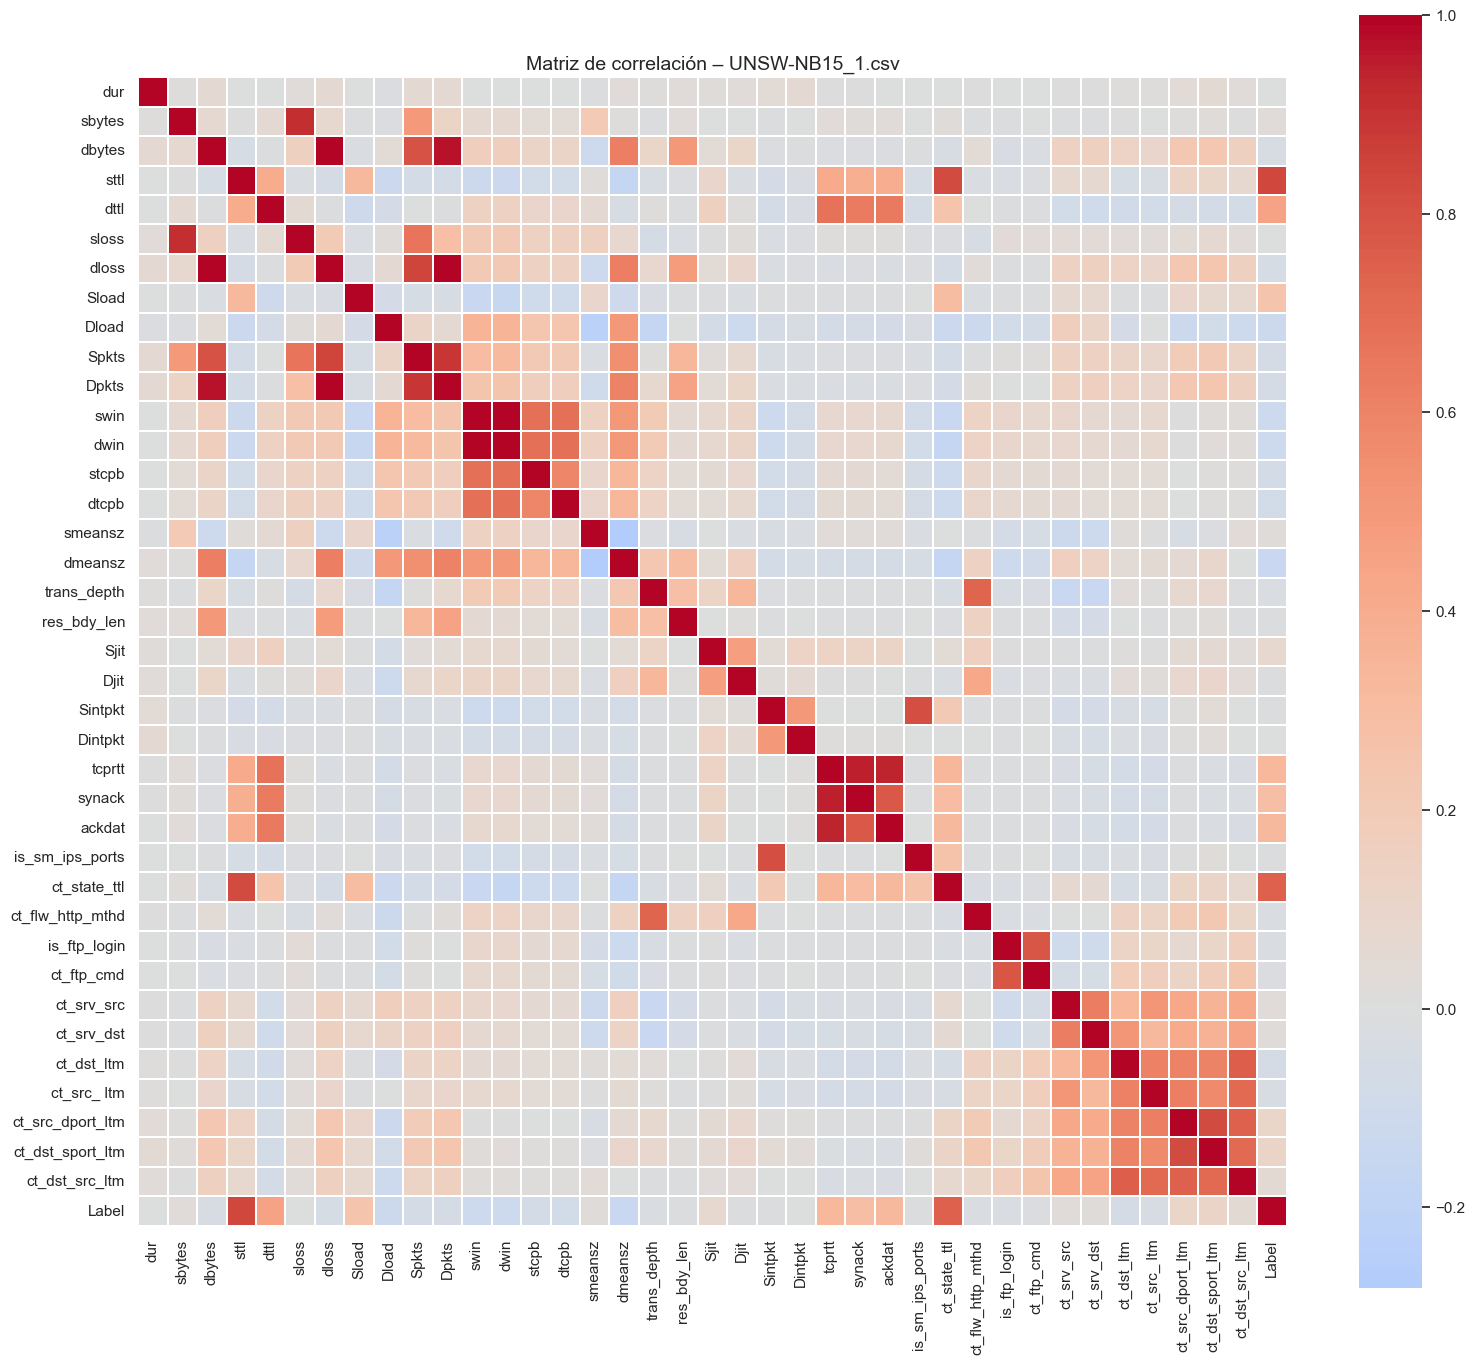


Top 20 correlaciones con Label:
sttl                0.836553
ct_state_ttl        0.742853
dttl                0.453985
tcprtt              0.331373
ackdat              0.328984
synack              0.296306
Sload               0.253598
dmeansz             0.136598
Dload               0.120050
swin                0.110972
dwin                0.110475
ct_dst_sport_ltm    0.110409
ct_src_dport_ltm    0.106179
dtcpb               0.076247
Sjit                0.075497
stcpb               0.074101
ct_dst_ltm          0.056345
Dpkts               0.055334
Spkts               0.054768
ct_dst_src_ltm      0.053946


In [12]:
# Excluir columnas de texto y timestamps Unix crudos
cols_excluir = ['srcip', 'dstip', 'proto', 'state', 'service',
                'attack_cat', 'Stime', 'Ltime']

df_corr = (
    df
    .drop(columns=cols_excluir, errors='ignore')
    .select_dtypes(include=["number"])
    .replace([np.inf, -np.inf], np.nan)
)

corr_matrix = df_corr.corr(method="pearson")

plt.figure(figsize=(16, 14))

sns.heatmap(
    corr_matrix,
    annot=False,      # con ~45 columnas numéricas, annot=True queda ilegible
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.2
)

plt.title(f"Matriz de correlación – {nombre_archivo}", fontsize=14)
plt.tight_layout()
plt.show()

# Correlaciones más altas con Label
print("\nTop 20 correlaciones con Label:")
print(
    corr_matrix["Label"]
    .drop("Label")
    .abs()
    .sort_values(ascending=False)
    .head(20)
    .to_string()
)

In [10]:
archivos_adf = sorted([
    f for f in glob.glob(os.path.join(processed_data, "*.csv"))
    if "features" not in os.path.basename(f).lower()
])

variables_adf = [
    "Sload",
    "Sintpkt",
    "smeansz",
]

muestra = 10000

for archivo in archivos_adf:
    nombre = os.path.basename(archivo)
    print("\n")
    print(nombre)

    df_tmp = pd.read_csv(
        archivo,
        header=None,
        names=FEATURE_NAMES,
        encoding='latin-1',
        low_memory=False
    )

    # Ordenar por Stime antes de calcular la ADF
    df_tmp = df_tmp.sort_values("Stime").reset_index(drop=True)

    for variable in variables_adf:
        serie = (
            df_tmp[variable]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
            .iloc[:muestra]
        )

        resultado = adfuller(serie, maxlag=20, autolag=None)

        estacionaria = "Estacionaria" if resultado[1] < 0.05 else "No estacionaria"
        print(
            f"  {variable:15s}"
            f"  ADF={resultado[0]:10.4f}"
            f"  p={resultado[1]:.6f}"
            f"  {estacionaria}"
        )



UNSW-NB15_1.csv
  Sload            ADF=  -18.0622  p=0.000000  Estacionaria
  Sintpkt          ADF=  -18.9239  p=0.000000  Estacionaria
  smeansz          ADF=  -21.3068  p=0.000000  Estacionaria


UNSW-NB15_2.csv
  Sload            ADF=  -21.2814  p=0.000000  Estacionaria
  Sintpkt          ADF=  -20.1508  p=0.000000  Estacionaria
  smeansz          ADF=  -23.3964  p=0.000000  Estacionaria


UNSW-NB15_3.csv
  Sload            ADF=  -13.1263  p=0.000000  Estacionaria
  Sintpkt          ADF=  -19.8366  p=0.000000  Estacionaria
  smeansz          ADF=  -18.3117  p=0.000000  Estacionaria


UNSW-NB15_4.csv
  Sload            ADF=   -9.5521  p=0.000000  Estacionaria
  Sintpkt          ADF=  -20.5383  p=0.000000  Estacionaria
  smeansz          ADF=  -18.6192  p=0.000000  Estacionaria
